In [1]:
# Importing relevant packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import kagglehub

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.makedirs('./data', exist_ok=True)

path = kagglehub.dataset_download(
	"alexteboul/diabetes-health-indicators-dataset",
	output_dir='./data'
)

print("Path to dataset files:", path)

Path to dataset files: ./data


In [3]:
df = pd.read_csv("./data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [4]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [5]:
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

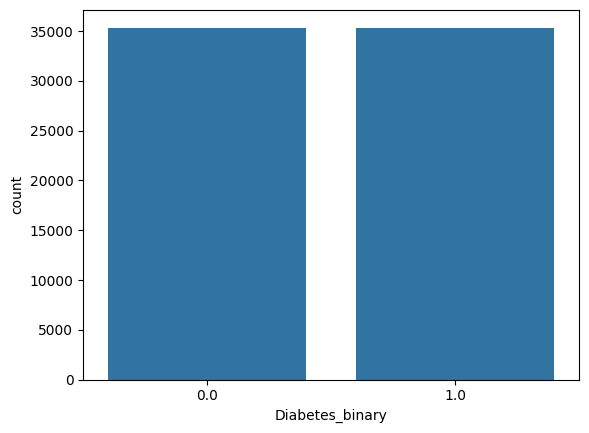

In [6]:
sns.countplot(data=df, x=df["Diabetes_binary"])
plt.show()

In [7]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

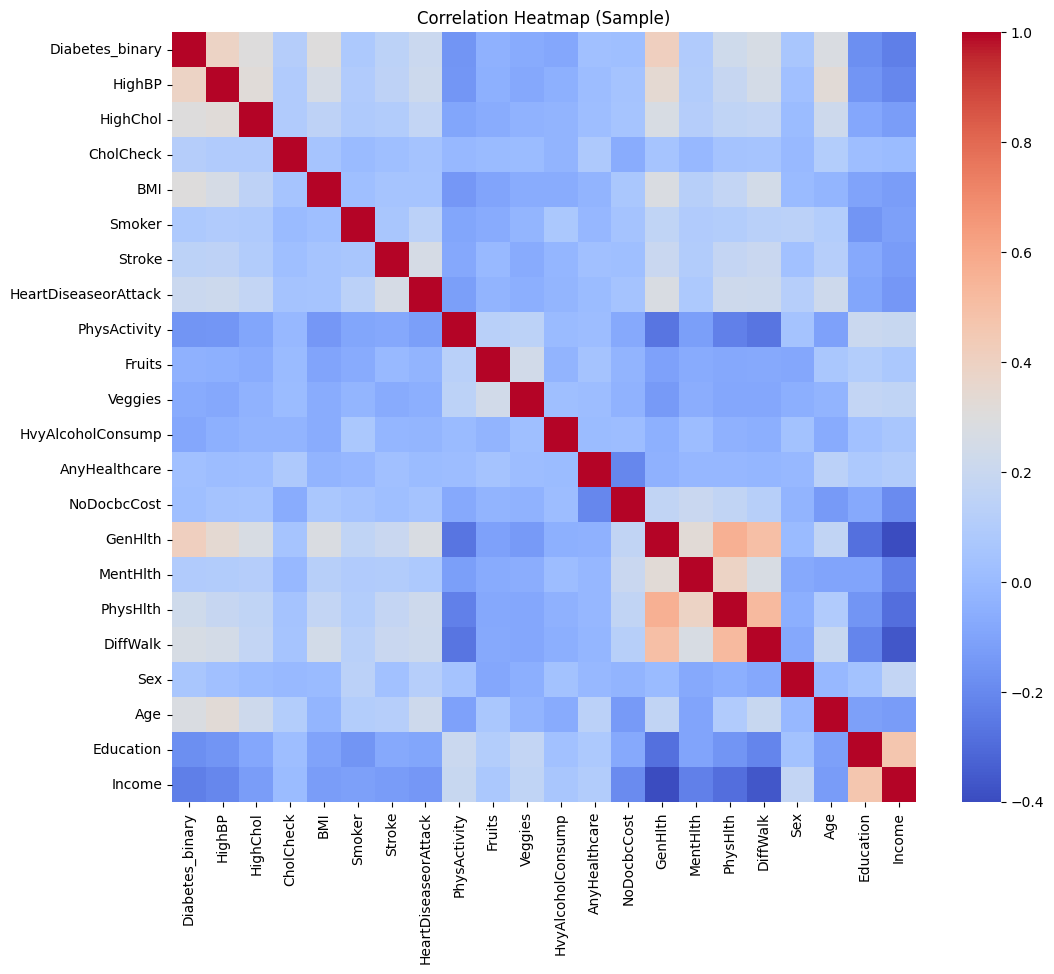

In [8]:
sample_df = df.sample(5000, random_state=42)
plt.figure(figsize=(12,10))
sns.heatmap(sample_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap (Sample)')
plt.show()

In [9]:
FEATURES_LIST = df.columns.to_list()[1:]
FEATURES_LIST

['HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [10]:
X = df[FEATURES_LIST]
y = df[df.columns[0]]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training dataset shape: {X_train.shape}, {y_train.shape}")
print(f"Testing dataset shape: {X_test.shape}, {y_test.shape}")

Training dataset shape: (56553, 21), (56553,)
Testing dataset shape: (14139, 21), (14139,)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42,
    )
}

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = [model, acc]

    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))


===== Logistic Regression =====
Accuracy: 0.745880189546644

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139

Confusion Matrix:
[[5145 1925]
 [1668 5401]]

===== Random Forest =====
Accuracy: 0.7324421812009336

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      7070
         1.0       0.72      0.77      0.74      7069

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139

Confusion Matrix:
[[4948 2122]
 [1661 5408]]

===== Gradient Boosting =====
Accuracy: 0.7536600891152132

Classification Report:
       

In [24]:
print("\nModel Performance Comparison:")
for k, v in results.items():
    print(f"{k}: {v[1]:.4f}")


Model Performance Comparison:
Logistic Regression: 0.7459
Random Forest: 0.7324
Gradient Boosting: 0.7537


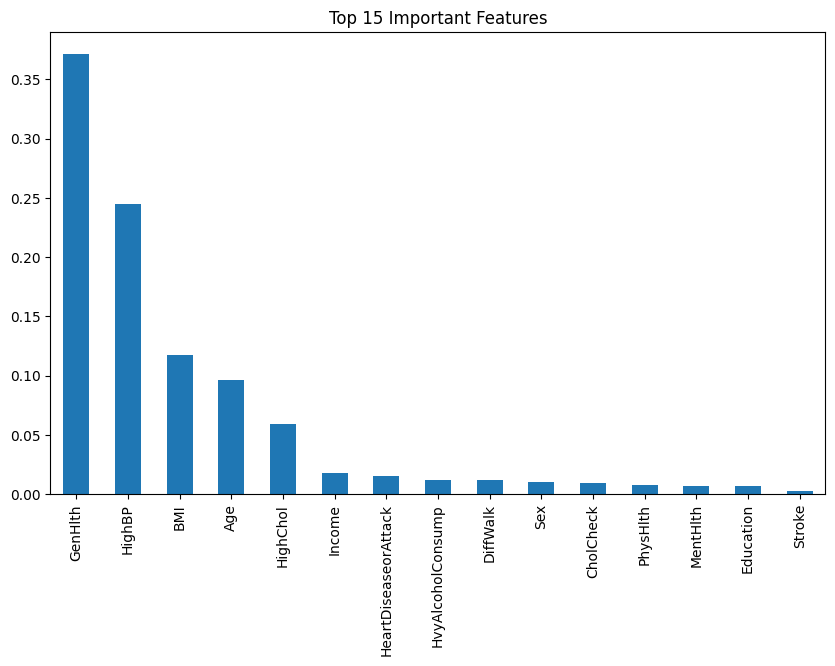

In [25]:
# Feature Important
gbc = results["Gradient Boosting"][0]

importances = gbc.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='bar')
plt.title('Top 15 Important Features')
plt.show()

In [26]:
gbc

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [27]:
import pickle

MODEL_DIR = "model"

os.makedirs(MODEL_DIR, exist_ok=True)
with open(os.path.join(MODEL_DIR, "model.pkl"), "wb") as f:
    pickle.dump(gbc, f)
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODEL_DIR, "feature_names.pkl"), "wb") as f:
    pickle.dump(FEATURES_LIST, f)